## **Import Modules**

In [ ]:
import os, urllib, tiktoken, torch, torch.nn as nn, numpy as np, pandas as pd

In [ ]:
from torch.utils.data import Dataset, DataLoader

In [ ]:
torch.manual_seed(123)

## **Read text file**

In [ ]:
file_path = 'the-verdict.txt'
url = 'https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch02/01_main-chapter-code/the-verdict.txt'

if not os.path.exists(file_path):
  with urllib.request.urlopen(url) as response:
    text_data = response.read().decode('utf-8') #bytes --> strings
  with open(file_path,'w', encoding='utf-8') as file:
    file.write(text_data)
else:
  with open(file_path, 'r', encoding='utf-8') as file:
    text_data = file.read()

In [ ]:
print(f'Total Characters: {len(text_data)}')

Total Characters: 20479


In [ ]:
text_data[:99]

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no '

In [ ]:
text_data[-99:]

'it for me! The Strouds stand alone, and happen once--but there\'s no exterminating our kind of art."'

In [ ]:
GPT_CONFIG_124M = {
    'vocab_size': 50257,
    'emb_dim': 768,
    'context_length': 256,
    'n_heads': 12,
    'n_layers': 12,
    'drop_rate': 0.1,
    'qkv_bias': True #kept TRUE to load OPENAI GPT-2 weights otherwise crash but modern LLMs keep it FALSE
}

## **QKV Bias**

**Training from scratch:**

**`qkv_bias=False`** is preferred — fewer parameters, no meaningful loss in accuracy
`LayerNorm` already centers the data before attention, so `qkv_bias` has nothing useful to shift
Modern LLMs (LLaMA, Mistral, Falcon) all use `qkv_bias=False` for this reason because Layer Norm's β parameter already handles the role of bias, so carrying explicit bias in Linear layers is redundant weight — drop it for free efficiency.

**Loading pretrained GPT-2 weights:**

OpenAI trained GPT-2 with QKV biases → checkpoint files contain bias values, So
we must set `qkv_bias=True` to create slots in your model to receive those values.

## **Create Data Batches**

In [ ]:
class GPTDataset(Dataset):
  def __init__(self, text_data, context_length, stride, tokenizer):
    self.input_ids = []
    self.target_ids = []

    token_ids = tokenizer.encode(text_data, allowed_special={'<|endoftext|>'})

    for i in range(0, len(token_ids)-context_length, stride):
      input_tokens = torch.tensor(token_ids[i:i+context_length])
      target_tokens = torch.tensor(token_ids[i+1:i+context_length+1])
      self.input_ids.append(input_tokens)
      self.target_ids.append(target_tokens)

  def __len__(self): #DataLoader calls this to know how many batches to create
    return len(self.input_ids)

  def __getitem__(self, idx): #DataLoader calls this repeatedly to fetch individual samples(one by one) and group them into batches
    return self.input_ids[idx], self.target_ids[idx]

In [ ]:
def create_dataloader(text_data, batch_size = 2, context_length = GPT_CONFIG_124M['context_length'],
                      stride = GPT_CONFIG_124M['context_length'], shuffle= True,
                      num_workers = 0, drop_last = True):

  tokenizer = tiktoken.encoding_for_model('gpt2')
  dataset = GPTDataset(text_data, context_length, stride, tokenizer)


  dataloader = DataLoader(
      dataset,
      batch_size = batch_size,
      shuffle = shuffle,  #It shuffles chunks of tokens first, then forms batches from the shuffled samples.
      drop_last= drop_last, #It drops the last batch if it has fewer samples than batch_size.
      num_workers = num_workers,
  )
  return dataloader

## **Split data into training and validation datasets**

In [ ]:
print(f'Total Characters: {len(text_data)}')

Total Characters: 20479


In [ ]:
# The split is purely character-based.
train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_set = text_data[:split_idx]
val_set = text_data[split_idx:]
print(len(train_set))
print(len(val_set))

18431
2048


In [ ]:
print(train_set[-30:])

 thing they called my 'techniq


In [ ]:
#Sanity check
tokenizer = tiktoken.encoding_for_model('gpt2')
train_tokens = tokenizer.encode(train_set, allowed_special={'<|endoftext|>'})
val_tokens = tokenizer.encode(val_set, allowed_special={'<|endoftext|>'})

if len(train_tokens) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for training loader...")

if len(val_tokens) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for validation loader...")

In [ ]:
train_loader = create_dataloader(train_set,
                                 batch_size = 2,
                                 context_length = GPT_CONFIG_124M["context_length"],
                                 stride = GPT_CONFIG_124M["context_length"],
                                 shuffle = True,
                                 num_workers = 0,
                                 drop_last = True
                                 )
val_loader = create_dataloader(val_set,
                               batch_size = 2,
                               context_length = GPT_CONFIG_124M["context_length"],
                               stride = GPT_CONFIG_124M["context_length"],
                               shuffle = False, #shufle during validation wont make any difference
                               num_workers = 0,
                               drop_last = True)

In [ ]:
print("Train Loader...")
for x, y in train_loader:
  print(x.shape, y.shape) #Each batch has two training examples

print("\nValidation Loader...")
for x, y in val_loader:
  print(x.shape, y.shape)

print("\nNum_batches_train_data: ", len(train_loader))
print("Num_batches_val_data: ", len(val_loader))

Train Loader...
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation Loader...
torch.Size([2, 256]) torch.Size([2, 256])

Num_batches_train_data:  9
Num_batches_val_data:  1


## **Create complete Transformer Model Architecture**

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self, cfg, eps = 1e-5):
    super().__init__() #super().__init__() calls the parent class constructor — in this case nn.Module.__init__().
    self.eps = eps     #without it parameters won't be tracked and training won't work.
    self.scale = nn.Parameter(torch.ones(cfg['emb_dim'])) #weight (trainable parameter)
    self.shift = nn.Parameter(torch.zeros(cfg['emb_dim'])) #bias  (trainable parameter)

  def forward(self, x):
    mean = torch.mean(x, dim = -1, keepdim = True)
    std = torch.std(x, dim = -1, keepdim = True)
    return self.scale * (x - mean) / (std + self.eps) + self.shift

class GELU(nn.Module): #GELU is applied element-wise
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2/torch.pi)) \
                                     * (x + 0.044715 * torch.pow(x,3))))

class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(nn.Linear(cfg['emb_dim'], 4*cfg['emb_dim']), #2 layers  (trainable parameter)
                            GELU(),
                            nn.Linear(4*cfg['emb_dim'], cfg['emb_dim']))              # (trainable parameter)

  def forward(self, x):
    return self.layers(x)

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, cfg): #Modern LLMS dont consider bias
    super().__init__()
    self.d_model = cfg['emb_dim']  #768
    self.n_heads = cfg['n_heads']  #12
    assert self.d_model % self.n_heads == 0
    self.head_dim = self.d_model // self.n_heads #floor (int) value #64
    self.qkv_bias = cfg['qkv_bias']
    self.dropout = nn.Dropout(cfg['drop_rate'])
    self.W_query = nn.Linear(self.d_model, self.d_model, bias = self.qkv_bias)
    self.W_key = nn.Linear(self.d_model, self.d_model, bias = self.qkv_bias)
    self.W_value = nn.Linear(self.d_model, self.d_model, bias = self.qkv_bias)
    self.register_buffer('causal_mask', torch.triu(torch.ones(cfg['context_length'],cfg['context_length']), diagonal = 1).bool()) #Registers the mask as a non-trainable tensor
    self.W_out = nn.Linear(self.d_model, self.d_model, bias = True) #kept TRUE to later load OPENAI GPT-2 weights otherwise for modern LLMs consider bias = False for training

  def forward(self, x):
    batch_size, num_tokens, _ = x.shape
    Q = self.W_query(x).reshape(batch_size, num_tokens, self.n_heads, self.head_dim) #(2,4,12,64)
    K = self.W_key(x).reshape(batch_size, num_tokens, self.n_heads, self.head_dim) #(2,4,12,64)
    V = self.W_value(x).reshape(batch_size, num_tokens, self.n_heads, self.head_dim) #(2,4,12,64)

    Q = Q.transpose(1,2) #(2,12,4,64)
    K = K.transpose(1,2) #(2,12,4,64)
    V = V.transpose(1,2) #(2,12,4,64)

    att_scores = Q @ K.transpose(-1, -2)/torch.sqrt(torch.tensor(self.head_dim)) #(2,12,4,4)
    att_scores = att_scores.masked_fill(self.causal_mask[:num_tokens, :num_tokens], -torch.inf) #(2,12,4,4)
    att_weights = torch.softmax(att_scores, dim = -1) #(2,12,4,4)
    att_weights = self.dropout(att_weights) #(2,12,4,4)
    context_vec = att_weights @ V #(2,12,4,64)
    context_vec = context_vec.transpose(1,2).reshape(batch_size, num_tokens, self.d_model)
    return self.W_out(context_vec)

In [ ]:
import torch

In [ ]:
torch.triu(torch.ones(4,4), diagonal = 1).bool()

tensor([[False,  True,  True,  True],
        [False, False,  True,  True],
        [False, False, False,  True],
        [False, False, False, False]])

In [ ]:
k = torch.randn(4,4)
print(k)
m = torch.triu(torch.ones(8,8), diagonal = 1).bool()
p = k.masked_fill(m[:4,:4], -torch.inf)
print(p)

tensor([[-0.7193, -0.2279,  0.6057,  2.1166],
        [-0.7040, -0.0169,  0.6692, -1.0891],
        [-0.2308, -0.5450,  0.6623, -0.8435],
        [ 0.4568,  0.9599,  0.2365, -1.5418]])
tensor([[-0.7193,    -inf,    -inf,    -inf],
        [-0.7040, -0.0169,    -inf,    -inf],
        [-0.2308, -0.5450,  0.6623,    -inf],
        [ 0.4568,  0.9599,  0.2365, -1.5418]])


In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.ln1 = LayerNorm(cfg)
    self.att = MultiHeadAttention(cfg)
    self.dropout = nn.Dropout(cfg['drop_rate'])
    self.ln2 = LayerNorm(cfg)
    self.ff = FeedForward(cfg)

  def forward(self, x):
    #To attention block
    shortcut = x
    x = self.ln1(x)
    x = self.att(x)
    x = self.dropout(x)
    x = x + shortcut

    #To feed-forward network
    shortcut = x
    x = self.ln2(x)
    x = self.ff(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [ ]:
class GPT2Model(nn.Module):
  def __init__ (self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
    self.pos_emb = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
    self.dropout = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks =nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg['n_layers'])])
    self.final_norm = LayerNorm(cfg)
    self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias = False) #Modern LLMs(even GPT2) don't consider it

  def forward(self, x):
    batch_size, num_tokens = x.shape
    tok_emb = self.tok_emb(x)
    pos_emb = self.pos_emb(torch.arange(num_tokens, device=x.device))
    x = tok_emb + pos_emb
    x = self.dropout(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

In [ ]:
model = GPT2Model(GPT_CONFIG_124M)

## **Total Trainable Parameters**

In [ ]:
print(f'Total Trainable Parameters: {sum(p.numel() for p in model.parameters()):,}') #approx 162 million trainable parameters

Total Trainable Parameters: 162,447,360


## **Model Training**

In [ ]:
def cal_batch_loss(input_batch, target_batch, model):
  logits = model(input_batch)
  loss = nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())
  return loss

def cal_loader_loss(loader, model):
  total_loss = 0.
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  for input_batch, target_batch in loader:
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    loss = cal_batch_loss(input_batch, target_batch, model)
    total_loss += loss.item()

  return total_loss/len(loader)

In [ ]:
print(f'Train Loss: {cal_loader_loss(train_loader, model)}')
print(f'Val Loss: {cal_loader_loss(val_loader, model)}')

Train Loss: 10.967689514160156
Val Loss: 10.98951530456543


In [ ]:
import matplotlib.pyplot as plt

def plot_losses(epochs_seen, train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_seen, train_losses, label="Training loss")
    plt.plot(epochs_seen, val_losses, linestyle="--", label="Validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig("loss_plot.png", dpi=150)
    plt.show()


Epoch 1: 

Train_Loss: 9.092887984381782
Val_Loss: 7.4397873878479

Epoch 2: 

Train_Loss: 6.531688743167454
Val_Loss: 6.48768949508667

Epoch 3: 

Train_Loss: 5.8121909565395775
Val_Loss: 6.390851974487305

Epoch 4: 

Train_Loss: 5.425249364640978
Val_Loss: 6.456839561462402

Epoch 5: 

Train_Loss: 4.97580083211263
Val_Loss: 6.379331111907959

Epoch 6: 

Train_Loss: 4.215766588846843
Val_Loss: 6.28446626663208

Epoch 7: 

Train_Loss: 3.522696680492825
Val_Loss: 6.284712314605713

Epoch 8: 

Train_Loss: 2.786528057522244
Val_Loss: 6.305090427398682

Epoch 9: 

Train_Loss: 2.1101909478505454
Val_Loss: 6.307138919830322

Epoch 10: 

Train_Loss: 1.526259634229872
Val_Loss: 6.419046401977539


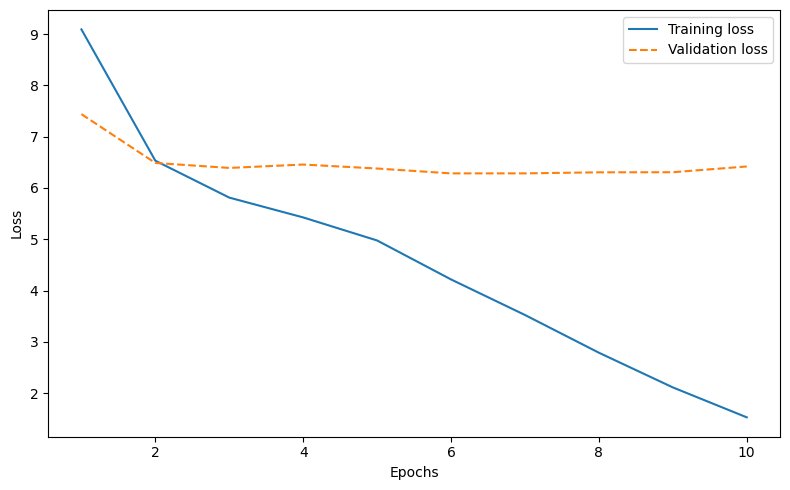

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0004, weight_decay = 0.1)
model.to(device) # modifies the model in-place — its internal tensors are moved
train_losses, val_losses, epochs_seen = [], [], []

model.train()
for epoch in range(10):
  total_loss = 0.
  for input_batch, target_batch in train_loader:
    input_batch, target_batch = input_batch.to(device), target_batch.to(device) #doesnt modify in-place, so reassigned
    optimizer.zero_grad()
    loss = cal_batch_loss(input_batch, target_batch, model)
    loss.backward()  #calculates gradients
    optimizer.step() #update weights
    total_loss += loss.item() #tensor --> float

  train_loss = total_loss / len(train_loader)
  print(f'\nEpoch {epoch+1}: \n')
  print(f'Train_Loss: {train_loss}')

  model.eval()
  with torch.no_grad():  # ✅ no computation graph created - no memory wasted
    val_loss = cal_loader_loss(val_loader, model)
  print(f'Val_Loss: {val_loss}')

   # Track losses
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  epochs_seen.append(epoch + 1)

  model.train()

plot_losses(epochs_seen, train_losses, val_losses)


In [ ]:
torch.save({'model_state_dict':model.state_dict(),
            'optimizer_state_dict':optimizer.state_dict()}, 'checkpoint.pth')

## **Saving and Loading model weights (and gradients)**

In [ ]:
checkpoint = torch.load('checkpoint.pth')

model = GPT2Model(GPT_CONFIG_124M)
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0004, weight_decay = 0.1)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

model.to(device)

GPT2Model(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (ln1): LayerNorm()
      (att): MultiHeadAttention(
        (dropout): Dropout(p=0.1, inplace=False)
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (W_out): Linear(in_features=768, out_features=768, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ln2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (ln1): LayerNorm()
      (att): MultiHeadAttention(
        (dropout): Dropout(p

## **Model Inference**

### **Temperature:**
**It controls the probability distribution.**

If temperature = 1, probabilities stay same

If temperature < 1, high probabilities become higher and low become even lower.

If temperature > 1, high probabilities become lower and low become little higher.

As temperature → 0, it becomes fully greedy (highest prob token always wins). As temperature → ∞, it becomes fully uniform (all tokens equally likely).

### How does `torch.multinomial()` works?

Token A: 0.6  → picked 60% of the time

Token B: 0.3  → picked 30% of the time  

Token C: 0.1  → picked 10% of the time

### **Top-k Sampling**

**Problem with temperature alone:** Any token can be randomly picked from the entire vocabulary. Tokens with very low probabilities can still get selected, potentially generating nonsensical text.

**Solution:** Top-k sampling restricts the candidate pool to only the most likely tokens.

---

**How it works:**

1. From the raw logits, keep only the top-k values — set all others to `-∞`
2. Apply softmax → `-∞` becomes `0`, redistributing probability only among top-k tokens
3. `torch.multinomial()` samples the next token exclusively from these top-k candidates

---

**Why top-k and temperature are always used together:**
- **Top-k** controls *which* tokens are candidates
- **Temperature** controls *how confidently* to pick among them

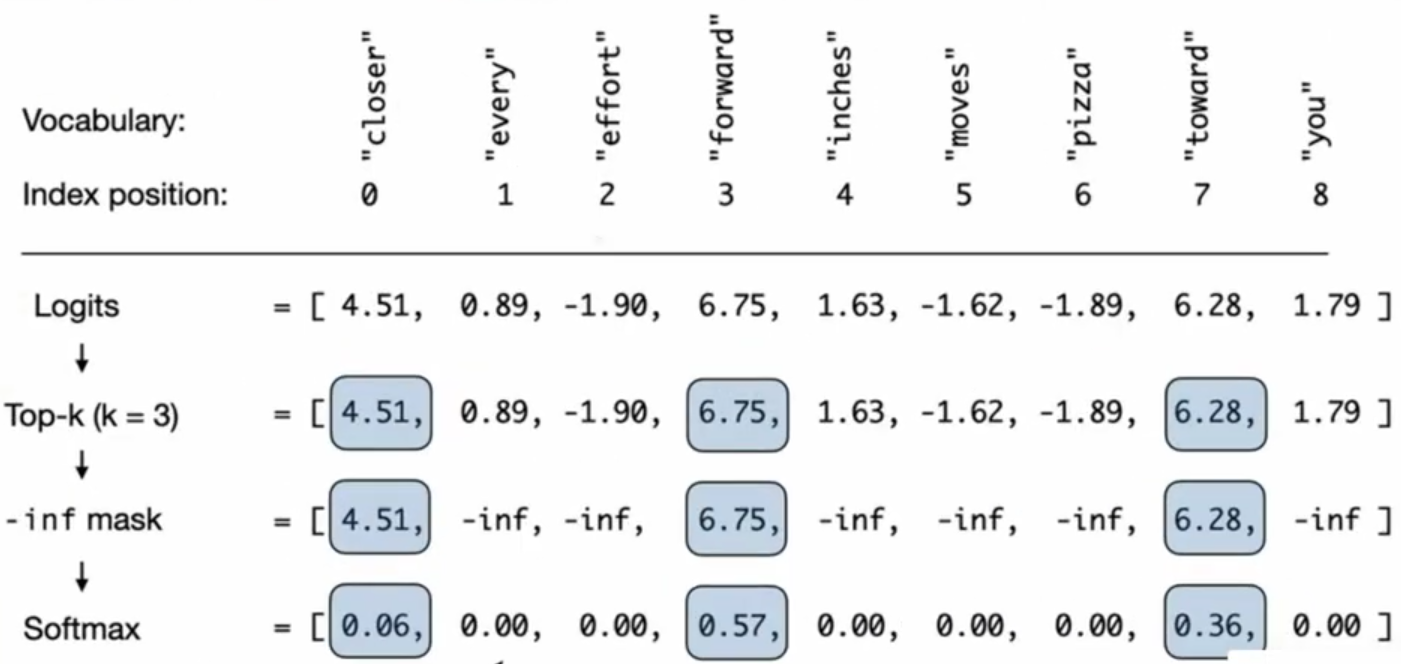

In [ ]:
#Passing a batch with only one input example
context = "Every effort moves you"
token_ids = torch.tensor(tokenizer.encode(context, allowed_special={'<|endoftext|>'}))
token_ids = token_ids.unsqueeze(0) #add batch dimension as model expects it
#print(token_ids.shape) #(1,4)

max_length = 25
top_k = 25
temperature = 1.4
context_size = GPT_CONFIG_124M["context_length"]

model.eval()
with torch.no_grad():
  for i in range(max_length):
    logits = model(token_ids)
    logits = logits[:, -1, :] #select last row
    top_values, top_indices = torch.topk(logits, k=top_k)
    min_val = top_values[:, -1] #selects the minimum value from each example in batch
    logits = torch.where(
        condition = logits < min_val,
        input = torch.tensor(float('-inf')),
        other = logits
    )
    input = logits/temperature #select last row of logits
    probs = torch.softmax(input, dim = -1)
    next_token_id = torch.multinomial(probs, num_samples = 1)
    token_ids = torch.cat([token_ids, next_token_id], dim = -1)

tokens = tokenizer.decode(token_ids.squeeze(0).tolist())
print(tokens)

Every effort moves you learned terr painting one of the Mrs. She or nervous and uncertain.

"Once."
Poor, the it to


## **Passing a batch with 2 example inputs of different length**

## GPT-2 has no padding concept by design — it was built for single-sequence autoregressive generation, not batched inputs of varying lengths.

In [ ]:
contexts = ["Every effort moves you", "The quick"]

token_ids_list = [tokenizer.encode(t, allowed_special = {'<|endoftext|>'}) for t in contexts]
max_len = max(len(t) for t in token_ids_list)
token_ids_list_padded = torch.tensor([t + [tokenizer.eot_token]*(max_len-len(t)) for t in token_ids_list])

max_length = 25
top_k = 25
temperature = 1.4
context_size = GPT_CONFIG_124M["context_length"]

model.eval()
with torch.no_grad():
  for i in range(max_length):
    logits = model(token_ids_list_padded)
    logits = logits[:, -1, :] #select last row
    top_values, top_indices = torch.topk(logits, k=top_k)
    min_val = top_values[:, -1].unsqueeze(1) # <-- CHANGE [2] → [2, 1]
    logits = torch.where(
        condition = logits < min_val,
        input = torch.tensor(float('-inf')),
        other = logits
    )
    input = logits/temperature #select last row of logits
    probs = torch.softmax(input, dim = -1)
    next_token_id = torch.multinomial(probs, num_samples = 1)
    token_ids_list_padded = torch.cat([token_ids_list_padded, next_token_id], dim = -1) # <-- CHANGE to token_ids_list_padded

# print(token_ids_list_padded.shape)

for row in token_ids_list_padded:
  tokens = tokenizer.decode(row.tolist())
  print(tokens)

Every effort moves you say that into so in the frame.
"I down, in a pur," he say it's "If in talking
The quick<|endoftext|><|endoftext|>?"Well would have a little wild--I laid_ his shoulders, at up all-confident moust went on everlasting


## **Loading GPT-2 Weights from OPENAI**

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,      # Vocabulary size
    "context_length": 1024,   # Context length (SHOULD MATCH THE GPT-2 ARCHITECTURE)
    "emb_dim": 768,           # Embedding dimension
    "n_heads": 12,            # Number of attention heads
    "n_layers": 12,           # Number of layers
    "drop_rate": 0.1,         # Dropout rate
    "qkv_bias": True         # Query-Key-Value bias
}

In [ ]:
model = GPT2Model(GPT_CONFIG_124M)

In [ ]:
# Download the script
import urllib
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch05/01_main-chapter-code/gpt_download.py",
    "gpt_download.py"
)

# Use it
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")
# settings tells you the architecture; params contains the actual pretrained weights you'll map into your GPTModel.

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 144kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.52MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 146kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:32<00:00, 15.5MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 9.68MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 2.24MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.79MiB/s]


In [ ]:
print(settings) # settings tells you the architecture;

{'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [ ]:
print(params.keys()) #params contains the actual pretrained weights you'll map into your GPTModel.

dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


```
params = {
    'wte': (50257, 768),      # token embeddings
    'wpe': (1024, 768),       # positional embeddings
    'blocks': [               # 12 transformer blocks
        {
            'attn': {'c_attn': ..., 'c_proj': ...},
            'mlp':  {'c_fc': ..., 'c_proj': ...},
            'ln_1': {'g': ..., 'b': ...},
            'ln_2': {'g': ..., 'b': ...},
        },
        ...
    ],
    'g': ..., 'b': ...        # final LayerNorm
}
```

In [ ]:
def assign(custom_value, openai_value):
  with torch.no_grad():
    if not isinstance(openai_value, torch.Tensor):
      openai_value = torch.tensor(openai_value)
    openai_value = openai_value.to(dtype=custom_value.dtype, device=custom_value.device)
    custom_value.copy_(openai_value)

In [ ]:
def load_weights_into_gpt2(model, params):
  assign(model.tok_emb.weight, params['wte'])
  assign(model.pos_emb.weight, params['wpe'])

  for b in range(GPT_CONFIG_124M ['n_layers']):

    #Copy Attention weights into the model
    q_w, k_w, v_w = np.split(params['blocks'][b]['attn']['c_attn']['w'], 3, axis = -1)
    assign(model.trf_blocks[b].att.W_query.weight, q_w.T)
    assign(model.trf_blocks[b].att.W_key.weight, k_w.T)
    assign(model.trf_blocks[b].att.W_value.weight, v_w.T)

    q_b, k_b, v_b = np.split(params['blocks'][b]['attn']['c_attn']['b'], 3, axis = -1)
    assign(model.trf_blocks[b].att.W_query.bias, q_b)
    assign(model.trf_blocks[b].att.W_key.bias, k_b)
    assign(model.trf_blocks[b].att.W_value.bias, v_b)

    assign(model.trf_blocks[b].att.W_out.weight, params['blocks'][b]['attn']['c_proj']['w'].T)
    assign(model.trf_blocks[b].att.W_out.bias, params['blocks'][b]['attn']['c_proj']['b'])

    #Copy Feedforward weights into the model
    assign(model.trf_blocks[b].ff.layers[0].weight, params['blocks'][b]['mlp']['c_fc']['w'].T)
    assign(model.trf_blocks[b].ff.layers[0].bias, params['blocks'][b]['mlp']['c_fc']['b'])
    assign(model.trf_blocks[b].ff.layers[2].weight, params['blocks'][b]['mlp']['c_proj']['w'].T)
    assign(model.trf_blocks[b].ff.layers[2].bias, params['blocks'][b]['mlp']['c_proj']['b'])

    #Copy Layer Norm weights into the model
    assign(model.trf_blocks[b].ln1.scale, params['blocks'][b]['ln_1']['g'])
    assign(model.trf_blocks[b].ln1.shift, params['blocks'][b]['ln_1']['b'])
    assign(model.trf_blocks[b].ln2.scale, params['blocks'][b]['ln_2']['g'])
    assign(model.trf_blocks[b].ln2.shift, params['blocks'][b]['ln_2']['b'])

  #Copy Final Layer Norm weights into the model
  assign(model.final_norm.scale, params['g'])
  assign(model.final_norm.shift, params['b'])
  assign(model.out_head.weight, params['wte'])

In [ ]:
load_weights_into_gpt2(model, params)

In [ ]:
#Passing a batch with only one input example
context = "Every effort moves you"
token_ids = torch.tensor(tokenizer.encode(context, allowed_special={'<|endoftext|>'}))
token_ids = token_ids.unsqueeze(0) #add batch dimension as model expects it
#print(token_ids.shape) #(1,4)

max_length = 25
top_k = 25
temperature = 1.4
context_size = GPT_CONFIG_124M["context_length"]

model.eval()
with torch.no_grad():
  for i in range(max_length):
    logits = model(token_ids)
    logits = logits[:, -1, :] #select last row
    top_values, top_indices = torch.topk(logits, k=top_k)
    min_val = top_values[:, -1] #selects the minimum value from each example in batch
    logits = torch.where(
        condition = logits < min_val,
        input = torch.tensor(float('-inf')),
        other = logits
    )
    input = logits/temperature #select last row of logits
    probs = torch.softmax(input, dim = -1)
    next_token_id = torch.multinomial(probs, num_samples = 1)
    token_ids = torch.cat([token_ids, next_token_id], dim = -1)

tokens = tokenizer.decode(token_ids.squeeze(0).tolist())
print(tokens)

Every effort moves you forward, but your past is the last you'll remember." (The Last Words and the Gospel of John.) If a person


## **What is Fine-Tuning?**

Fine-tuning LLM involves the additional training of a pre-existing model which has previously acquired patterns and features from an extensive dataset, using a smaller, domain-specific dataset.

**Instruction fine-tuning**

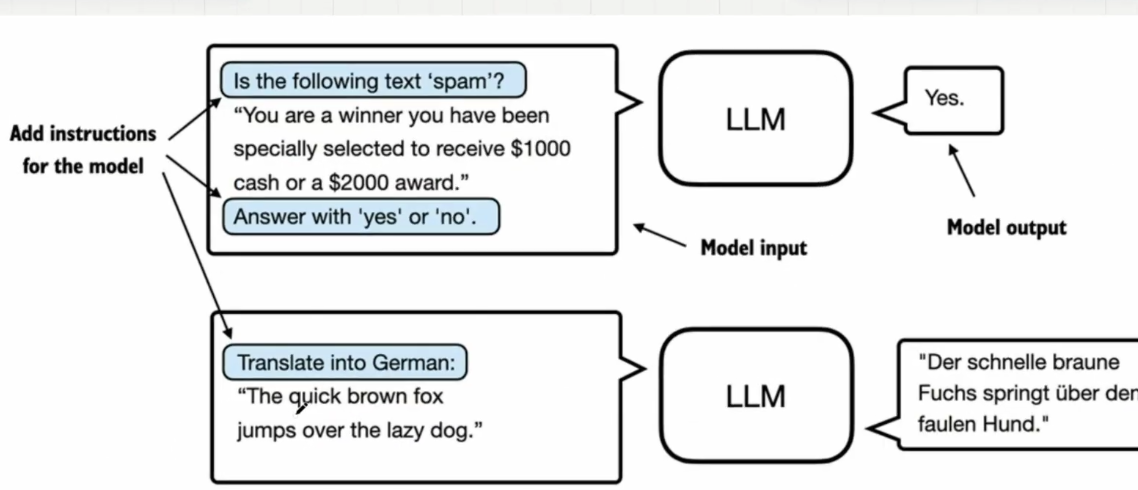

**Classification Fine-tuning**

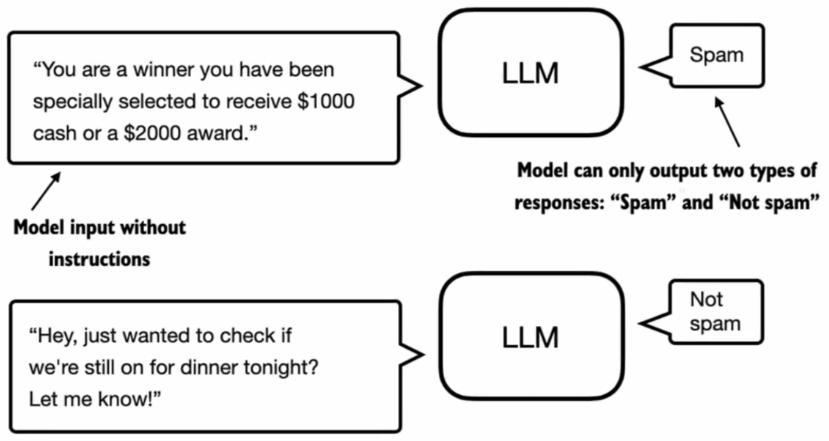

## **Instruction fine-tuning needs a larger dataset and high computational power over classification fine-tuning because:**

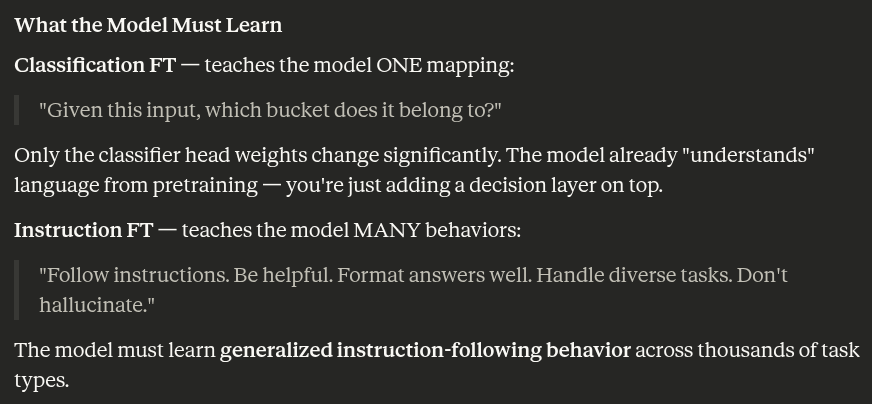

Because instruction fine-tuning updates the entire model over long sequences and diverse tasks, it demands significant compute and memory. **Parameter-Efficient Fine-Tuning (PEFT)** addresses the high compute/memory problem by freezing most model weights and training only a small set of additional parameters. **PEFT** is a broad family of methods; the two most widely used are:

**LoRA**— injects trainable low-rank matrices into attention layers

**QLoRA**— combines LoRA with 4-bit quantization for even lower memory usage

While **PEFT** is most valuable for instruction fine-tuning, it can also be applied to classification fine-tuning when the base model is large.

## **Implementing Classification Fine-Tuning**

In [ ]:
from google.colab import files #Download from https://archive.ics.uci.edu/dataset/228/sms+spam+collection
uploaded = files.upload()  # opens a file picker

In [ ]:
df = pd.read_csv('/content/SMSSpamCollection', names = ['label', 'Text'], sep='\t')
df

,label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [ ]:
def create_balanced_dataset(df):
  num_samples = df[df['label'] == 'spam'].shape[0]

  spam_df = df[df['label'] == 'spam']
  ham_df = df[df['label'] == 'ham'].sample(num_samples) # randomly selects n rows from the DataFrame

  balanced_df = pd.concat([spam_df, ham_df])
  print(balanced_df['label'].value_counts())

  return balanced_df

df = create_balanced_dataset(df)

label
spam    747
ham     747
Name: count, dtype: int64


In [ ]:
df

,label,Text
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
3170,ham,"Haven't seen my facebook, huh? Lol!"
3028,ham,You still at the game?
5417,ham,Nope. I just forgot. Will show next week
2667,ham,"* Was a nice day and, impressively, i was sens..."


In [ ]:
df['label'] = df['label'].map({'spam':1, 'ham':0})
df

,label,Text
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
5,1,FreeMsg Hey there darling it's been 3 week's n...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...
11,1,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
3170,0,"Haven't seen my facebook, huh? Lol!"
3028,0,You still at the game?
5417,0,Nope. I just forgot. Will show next week
2667,0,"* Was a nice day and, impressively, i was sens..."


In [ ]:
def random_split(df, train_ratio, val_ratio):
  df = df.sample(frac = 1) #shuffle and pick 100% of the rows

  train_size = int(len(df) * train_ratio)
  val_size = int(len(df) * val_ratio)
  train_df = df[:train_size]
  val_df = df[train_size:train_size + val_size]
  test_df = df[train_size + val_size:]

  return train_df, val_df, test_df

train_df, val_df, test_df = random_split(df, 0.7, 0.1)

print(f'train_df: {train_df.shape}')
print(f'val_df: {val_df.shape}')
print(f'test_df: {test_df.shape}')


train_df: (1045, 2)
val_df: (149, 2)
test_df: (300, 2)


In [ ]:
train_df.to_csv('train.csv', index = False)
val_df.to_csv('val.csv', index = False)
test_df.to_csv('test.csv', index = False)